In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/missing_handled_data.csv")

In [2]:
df["displacement"]

0        1422.0
1        1798.0
2        1598.0
3        1422.0
4        1422.0
          ...  
14096    1598.0
14097    1461.0
14098    1798.0
14099    1798.0
14100    1997.0
Name: displacement, Length: 14101, dtype: float64

In [4]:
#Mark unrealistic values as missing:
df.loc[df["hp"] <= 0, "hp"] = np.nan
df.loc[df["hp"] > 500, "hp"] = np.nan

df.loc[df["displacement"] <= 0, "displacement"] = np.nan
df.loc[df["displacement"] > 8000, "displacement"] = np.nan

df.loc[df["weight"] <= 0, "weight"] = np.nan
df.loc[df["weight"] > 4000, "weight"] = np.nan

df.loc[df["price"] <= 0, "price"] = np.nan
df.loc[df["km"] < 0, "km"] = np.nan

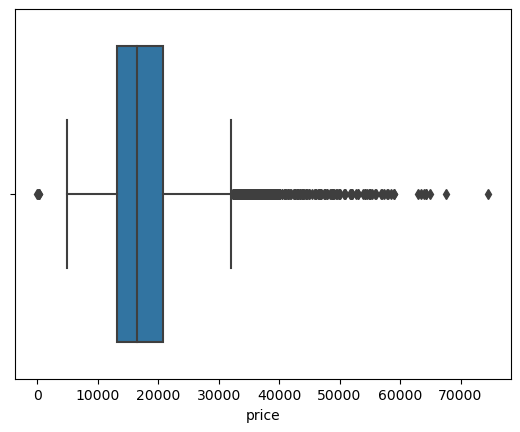

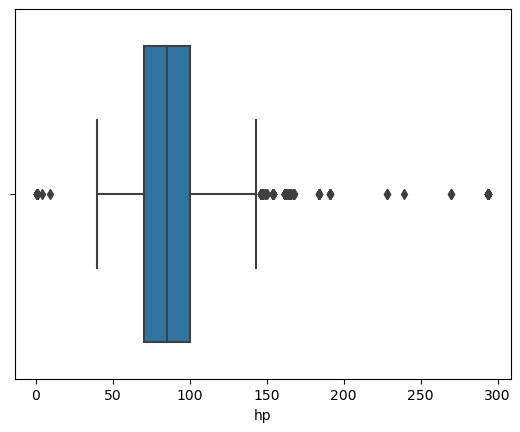

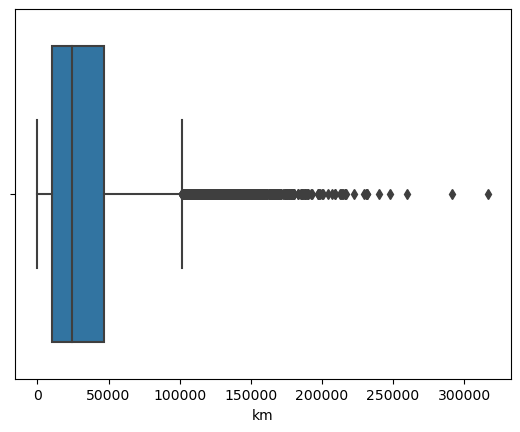

In [5]:
#visualize
sns.boxplot(x=df["price"])
plt.show()

sns.boxplot(x=df["hp"])
plt.show()

sns.boxplot(x=df["km"])
plt.show()

In [6]:
# Fill again
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df.groupby("make_model")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [7]:
df.to_csv("../data/processed/outlier_cleaned_data.csv", index=False)